# Flow Sample Diagnostics

Focused notebook for cached-sample diagnostics using hierarchical cache layout from [scr]_tf_analysis.py.

In [1]:
import json
import os
import sys
from os.path import join

# Add parent directory (arch/) to path so we can import sibling modules
# Handle both cases: notebook run from diagnostics/ or from arch/
current_dir = os.getcwd()
if 'diagnostics' in current_dir:
    arch_dir = os.path.dirname(current_dir)
else:
    arch_dir = current_dir

if arch_dir not in sys.path:
    sys.path.insert(0, arch_dir)

import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

import config
from utils import density_contour, img_to_gal_axis, make_corner_plot, make_g_contour

In [43]:
# Configure these paths and identifiers for your run
cache_root = '/ocean/projects/phy250048p/shared/cache'
fig_root = '/ocean/projects/phy250048p/shared/figures'
sample_csv = '/ocean/projects/phy250048p/shared/samples/samples_small_1m.csv'

model_name = 'CNN-CNN-flow_pretrained_CCL'
dataset_name = 'small_1m_tf_conformed'
os.makedirs(join(fig_root, model_name), exist_ok=True)
partitions = [f'part{i}of10' for i in range(10)]

# 0 -> mode 1 (no TF prior), 1 -> mode 2 (with TF prior)
mode_index = 0
vcirc_idx = 5

In [44]:
data_types = [
                # 'sample', 
                # 'log_prob', 
                'snr', 
                'truth', 
                'map_estimates', 
                'mean_estimates', 
                'meta'
            ]

def cache_path(data_type, partition, ext='npy'):
    if data_type not in data_types:
        raise ValueError(f'Unsupported data type: {data_type}')
    return join(cache_root, model_name, dataset_name, data_type, f'{partition}.{ext}')

def load_partition(data_types, partition):
    sample_path = cache_path('sample', partition) if 'sample' in data_types else None
    log_prob_path = cache_path('log_prob', partition) if 'log_prob' in data_types else None
    snr_path = cache_path('snr', partition) if 'snr' in data_types else None
    truth_path = cache_path('truth', partition) if 'truth' in data_types else None
    map_path = cache_path('map_estimates', partition) if 'map_estimates' in data_types else None
    mean_path = cache_path('mean_estimates', partition) if 'mean_estimates' in data_types else None
    meta_path = cache_path('meta', partition, ext='json') if 'meta' in data_types else None

    path_list = [sample_path, log_prob_path, snr_path, truth_path, map_path, mean_path, meta_path]
    required = [p for p in path_list if p is not None]
    missing = [p for p in required if not os.path.exists(p)]
    if missing:
        raise FileNotFoundError('Missing hierarchical cache files for partition '
                                f"{partition}: {missing}")

    with open(meta_path, 'r', encoding='ascii') as fp:
        meta = json.load(fp)

    return {
        'partition': partition,
        'sample': np.load(sample_path) if sample_path else None,
        'log_prob': np.load(log_prob_path) if log_prob_path else None,
        'snr': np.load(snr_path) if snr_path else None,
        'truth': np.load(truth_path) if truth_path else None,
        'map_estimates': np.load(map_path) if map_path else None,
        'mean_estimates': np.load(mean_path) if mean_path else None,
        'meta': meta,
    }

In [45]:
parts = [load_partition(data_types, p) for p in partitions]

samples = np.concatenate([p['sample'] for p in parts], axis=1) if 'sample' in data_types else None
log_probs = np.concatenate([p['log_prob'] for p in parts], axis=1) if 'log_prob' in data_types else None
snrs = np.concatenate([p['snr'] for p in parts], axis=0) if 'snr' in data_types else None
truths = np.concatenate([p['truth'] for p in parts], axis=0) if 'truth' in data_types else None
map_estimates = np.concatenate([p['map_estimates'] for p in parts], axis=1) if 'map_estimates' in data_types else None
mean_estimates = np.concatenate([p['mean_estimates'] for p in parts], axis=1) if 'mean_estimates' in data_types else None

ngals = truths.shape[0]

assert samples.shape[1] == ngals if samples is not None else True
assert log_probs.shape[1] == ngals if log_probs is not None else True
assert snrs.shape[0] == ngals if snrs is not None else True
assert map_estimates.shape[1] == ngals if map_estimates is not None else True
assert mean_estimates.shape[1] == ngals if mean_estimates is not None else True

In [46]:
sample_table = pd.read_csv(sample_csv)
theta = np.array(sample_table['theta_int'])[:ngals]

g1_true = truths[:, 0]
g2_true = truths[:, 1]
vcirc_true = truths[:, vcirc_idx]

g1_pred = map_estimates[mode_index, :, 0]
g2_pred = map_estimates[mode_index, :, 1]
vcirc_pred = map_estimates[mode_index, :, vcirc_idx]
# g1_pred = mean_estimates[mode_index, :, 1, 0]
# g2_pred = mean_estimates[mode_index, :, 1, 1]
# vcirc_pred = mean_estimates[mode_index, :, 1, vcirc_idx]

g1_diff = g1_pred - g1_true
g2_diff = g2_pred - g2_true
vcirc_diff = vcirc_pred - vcirc_true

gp_true, gc_true = img_to_gal_axis(g1_true, g2_true, theta)
gp_pred, gc_pred = img_to_gal_axis(g1_pred, g2_pred, theta)
gp_diff = gp_pred - gp_true
gc_diff = gc_pred - gc_true

In [20]:
from data import TFCalculator, snr_to_app_mag
tfcalc = TFCalculator(slope=-7.22, intercept=36)
app_mag = snr_to_app_mag(snrs)
vcirc_expected = tfcalc.mag_to_vcirc(app_mag)
vcirc_diff_tf = vcirc_true - vcirc_expected
mask_within_tf = np.abs(vcirc_diff_tf) < 40

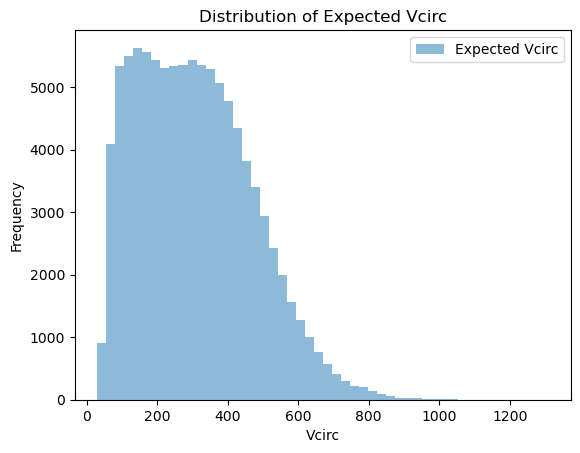

In [21]:
plt.hist(vcirc_expected, bins=50, alpha=0.5, label='Expected Vcirc')
plt.xlabel('Vcirc')
plt.ylabel('Frequency')
plt.title('Distribution of Expected Vcirc')
plt.legend()
plt.show()

In [47]:
# snr_mask = (snrs >= 5) & (snrs <= 1000)
snr_mask = snrs > 0
# snr_mask = mask_within_tf
g1_diff_masked = g1_diff[snr_mask]
g2_diff_masked = g2_diff[snr_mask]

In [23]:
snr_bin_centers = np.arange(0, 1000, 50) + 25
snr_bin_edges = np.arange(0, 1000 + 25, 50)
# snr_bin_indices = np.digitize(snrs, snr_bin_edges) - 1
snr_bin_indices = np.digitize(snrs[snr_mask], snr_bin_edges) - 1
# snr_bin_indices = np.digitize(snrs[mask_within_tf], snr_bin_edges) - 1

In [24]:
g1_diff_avgs = []
g2_diff_avgs = []
g1_diff_errs = []
g2_diff_errs = []
for i in range(20):
    g1_diff_bin = g1_diff_masked[snr_bin_indices == i]
    g2_diff_bin = g2_diff_masked[snr_bin_indices == i]
    g1_diff_avgs.append(np.mean(g1_diff_bin))
    g2_diff_avgs.append(np.mean(g2_diff_bin))
    g1_diff_errs.append(np.std(g1_diff_bin)/np.sqrt(len(g1_diff_bin)))
    g2_diff_errs.append(np.std(g2_diff_bin)/np.sqrt(len(g2_diff_bin)))

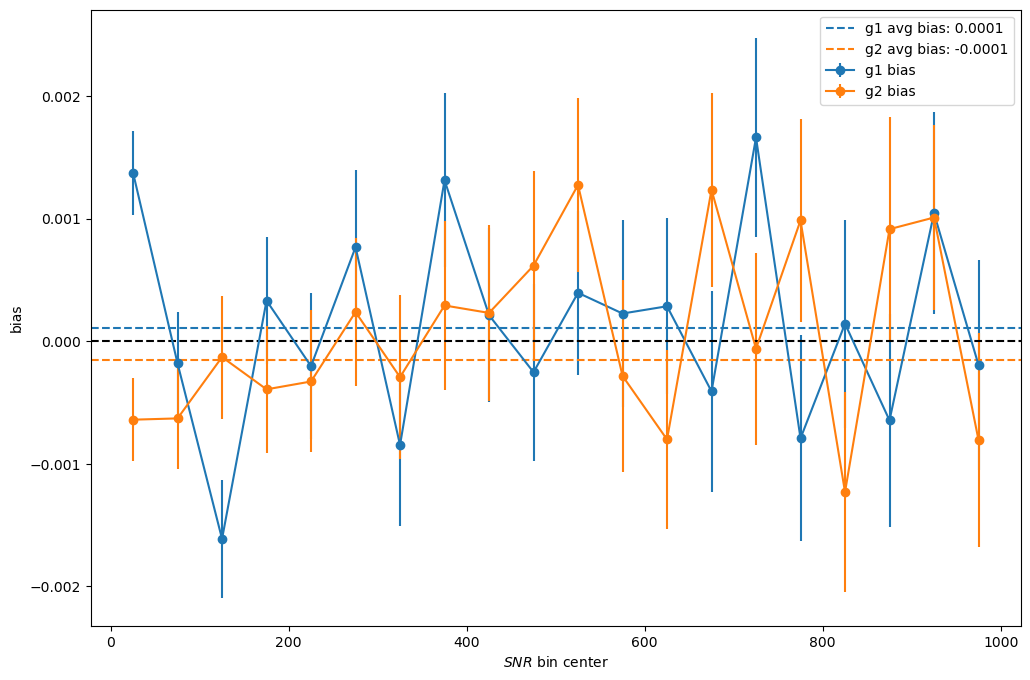

In [25]:
plt.figure(figsize=(12, 8))
plt.errorbar(snr_bin_centers, g1_diff_avgs, yerr=g1_diff_errs, marker='o', label='g1 bias')
plt.axhline(np.mean(g1_diff_masked), linestyle='--', color='C0', label=f'g1 avg bias: {np.mean(g1_diff_masked):.4f}')
plt.errorbar(snr_bin_centers, g2_diff_avgs, yerr=g2_diff_errs, marker='o', label='g2 bias')
plt.axhline(np.mean(g2_diff_masked), linestyle='--', color='C1', label=f'g2 avg bias: {np.mean(g2_diff_masked):.4f}')
plt.axhline(0, linestyle='--', color='black')
plt.xlabel(r'$SNR$ bin center')
plt.ylabel('bias')
plt.legend()
plt.savefig(join(fig_root, model_name,'g_bias_vs_snr_tf_conformed.png'), dpi=300, bbox_inches='tight')
plt.show()

In [26]:
theta_bin_centers = np.arange(-np.pi, np.pi, np.pi/8)+np.pi/16
theta_bin_edges = np.arange(-np.pi, np.pi+1e-6, np.pi/8)
theta_bin_indices = np.digitize(theta[snr_mask], theta_bin_edges) - 1

In [27]:
g1_diff_avgs = []
g2_diff_avgs = []
g1_diff_errs = []
g2_diff_errs = []
for i in range(16):
    g1_diff_bin = g1_diff_masked[theta_bin_indices == i]
    g2_diff_bin = g2_diff_masked[theta_bin_indices == i]
    g1_diff_avgs.append(np.mean(g1_diff_bin))
    g2_diff_avgs.append(np.mean(g2_diff_bin))
    g1_diff_errs.append(np.std(g1_diff_bin)/np.sqrt(len(g1_diff_bin)))
    g2_diff_errs.append(np.std(g2_diff_bin)/np.sqrt(len(g2_diff_bin)))

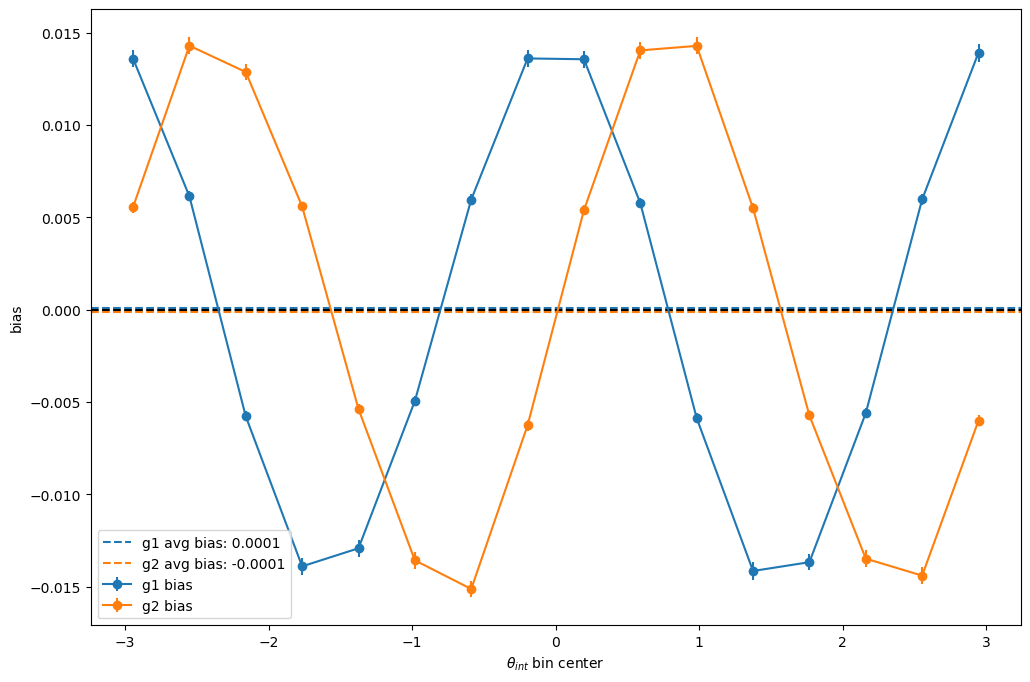

In [28]:
plt.figure(figsize=(12, 8))
plt.errorbar(theta_bin_centers, g1_diff_avgs, yerr=g1_diff_errs, marker='o', label='g1 bias')
plt.axhline(np.mean(g1_diff_masked), linestyle='--', color='C0', label=f'g1 avg bias: {np.mean(g1_diff_masked):.4f}')
plt.errorbar(theta_bin_centers, g2_diff_avgs, yerr=g2_diff_errs, marker='o', label='g2 bias')
plt.axhline(np.mean(g2_diff_masked), linestyle='--', color='C1', label=f'g2 avg bias: {np.mean(g2_diff_masked):.4f}')
plt.axhline(0, linestyle='--', color='black')
plt.xlabel(r'$\theta_{int}$ bin center')
plt.ylabel('bias')
plt.legend()
plt.savefig(join(fig_root, model_name,'g_bias_vs_theta_tf_conformed.png'), dpi=300, bbox_inches='tight')
plt.show()

In [29]:
sini_bin_centers = np.arange(0, 1, 0.1)+0.05
sini_bin_edges = np.arange(0, 1.01, 0.1)
sini_bin_indices = np.digitize(truths[:, 3][snr_mask], sini_bin_edges) - 1

In [30]:
gp_diff_avgs = []
gc_diff_avgs = []
gp_diff_errs = []
gc_diff_errs = []
for i in range(len(sini_bin_centers)):
    gp_diff_bin = gp_diff_masked[sini_bin_indices == i]
    gc_diff_bin = gc_diff_masked[sini_bin_indices == i]
    gp_diff_avgs.append(np.mean(gp_diff_bin))
    gc_diff_avgs.append(np.mean(gc_diff_bin))
    gp_diff_errs.append(np.std(gp_diff_bin)/np.sqrt(len(gp_diff_bin)))
    gc_diff_errs.append(np.std(gc_diff_bin)/np.sqrt(len(gc_diff_bin)))

NameError: name 'gp_diff_masked' is not defined

In [ ]:
g1_diff_avgs = []
g2_diff_avgs = []
g1_diff_errs = []
g2_diff_errs = []
for i in range(len(sini_bin_centers)):
    g1_diff_bin = g1_diff_masked[sini_bin_indices == i]
    g2_diff_bin = g2_diff_masked[sini_bin_indices == i]
    g1_diff_avgs.append(np.mean(g1_diff_bin))
    g2_diff_avgs.append(np.mean(g2_diff_bin))
    g1_diff_errs.append(np.std(g1_diff_bin)/np.sqrt(len(g1_diff_bin)))
    g2_diff_errs.append(np.std(g2_diff_bin)/np.sqrt(len(g2_diff_bin)))

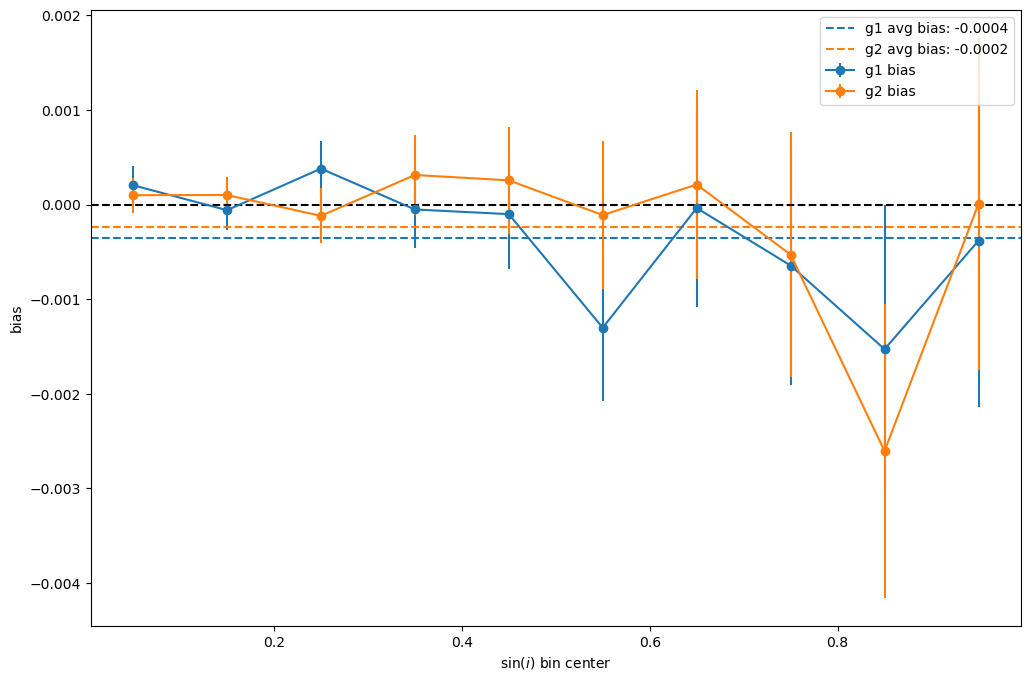

In [ ]:
plt.figure(figsize=(12, 8))
plt.errorbar(sini_bin_centers, g1_diff_avgs, yerr=g1_diff_errs, marker='o', label='g1 bias')
plt.axhline(np.mean(g1_diff_masked), linestyle='--', color='C0', label=f'g1 avg bias: {np.mean(g1_diff_masked):.4f}')
plt.errorbar(sini_bin_centers, g2_diff_avgs, yerr=g2_diff_errs, marker='o', label='g2 bias')
plt.axhline(np.mean(g2_diff_masked), linestyle='--', color='C1', label=f'g2 avg bias: {np.mean(g2_diff_masked):.4f}')
plt.axhline(0, linestyle='--', color='black')
plt.xlabel(r'$\sin(i)$ bin center')
plt.ylabel('bias')
plt.legend()
plt.savefig(join(fig_root, model_name,'g12_bias_vs_sini_tf_conformed.png'), dpi=300, bbox_inches='tight')
plt.show()

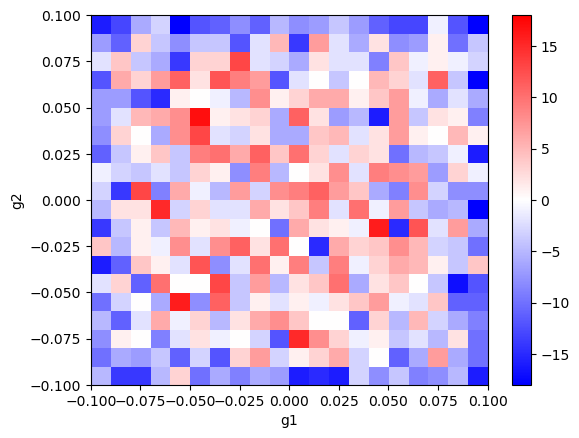

In [ ]:
counts_pred, _, _, _ = plt.hist2d(g1_pred, g2_pred, bins=20, range=[[-0.1, 0.1], [-0.1, 0.1]])
counts_true, _, _, _ = plt.hist2d(g1_true, g2_true, bins=20, range=[[-0.1, 0.1], [-0.1, 0.1]])
plt.close()
counts_diff = counts_pred - counts_true
plt.imshow(counts_diff.T, origin='lower', extent=[-0.1, 0.1, -0.1, 0.1], cmap='bwr', aspect='auto', norm=colors.CenteredNorm(vcenter=0.0))
plt.xlabel('g1')
plt.ylabel('g2')
plt.colorbar()

In [ ]:
diffs_avg = np.mean(map_estimates[0, :, :][snr_mask] - truths[snr_mask], axis=0)
diffs_err = np.std(map_estimates[0, :, :][snr_mask] - truths[snr_mask], axis=0) / np.sqrt(np.sum(snr_mask))
# diffs_avg_tf = np.mean(map_estimates[1, :, :] - truths, axis=0)
# diffs_err_tf = np.std(map_estimates[1, :, :] - truths, axis=0) / np.sqrt(map_estimates.shape[1])

In [ ]:
print('biases for each parameter:')
for i, param in enumerate(config.par_ranges.keys()):
    print(f'{param}: {diffs_avg[i]:.6f} ± {diffs_err[i]:.6f}')

biases for each parameter:
g1: -0.000352 ± 0.000306
g2: -0.000237 ± 0.000307
theta_int: -0.680912 ± 0.021089
sini: -0.023885 ± 0.000801
v0: -0.026234 ± 0.021288
vcirc: 9.227029 ± 0.498668
rscale: -0.032227 ± 0.003240
hlr: -0.022712 ± 0.000897


IndexError: index 8 is out of bounds for axis 0 with size 8

In [ ]:
print('biases for each parameter (w/ tf):')
for i, param in enumerate(config.par_ranges.keys()):
    print(f'{param}: {diffs_avg_tf[i]:.6f} ± {diffs_err_tf[i]:.6f}')

biases for each parameter (w/ tf):


NameError: name 'diffs_avg_tf' is not defined

In [ ]:
print('shear additive bias (gal axis, no tf prior)')
print('g+:', f'{np.mean(gp_diff):.6f} ± {np.std(gp_diff)/np.sqrt(len(gp_diff)):.6f}')
print('gx:', f'{np.mean(gc_diff):.6f} ± {np.std(gc_diff)/np.sqrt(len(gc_diff)):.6f}')

shear additive bias (gal axis, no tf prior)
g+: -0.000125 ± 0.000100
gx: -0.000253 ± 0.000100


In [ ]:
print('shear additive bias (gal axis, w/ tf prior)')
print('g+:', f'{np.mean(gp_diff):.6f} ± {np.std(gp_diff)/np.sqrt(len(gp_diff)):.6f}')
print('gx:', f'{np.mean(gc_diff):.6f} ± {np.std(gc_diff)/np.sqrt(len(gc_diff)):.6f}')

shear additive bias (gal axis, w/ tf prior)
g+: 0.000558 ± 0.000271
gx: -0.000099 ± 0.000271


In [ ]:
print('shear additive bias (no tf prior)')
print('g1:', f'{np.mean(g1_diff):.6f} ± {np.std(g1_diff)/np.sqrt(len(g1_diff)):.6f}')
print('g2:', f'{np.mean(g2_diff):.6f} ± {np.std(g2_diff)/np.sqrt(len(g2_diff)):.6f}')

shear additive bias (no tf prior)
g1: 0.000171 ± 0.000050
g2: -0.000321 ± 0.000052


In [ ]:
print('shear additive bias (w/ tf prior)')
print('g1:', f'{np.mean(g1_diff):.6f} ± {np.std(g1_diff)/np.sqrt(len(g1_diff)):.6f}')
print('g2:', f'{np.mean(g2_diff):.6f} ± {np.std(g2_diff)/np.sqrt(len(g2_diff)):.6f}')

shear additive bias (w/ tf prior)
g1: -0.000084 ± 0.000280
g2: -0.000328 ± 0.000261


In [ ]:
from plots import ParameterContourPlotter

plotter = ParameterContourPlotter(
    model_name=model_name,
    true=truths[snr_mask],
    pred=map_estimates[0][snr_mask],
    # pred_tf=map_estimates[1],
    snr=snrs[snr_mask],
    feature_names=config.train['feature_names'],
)

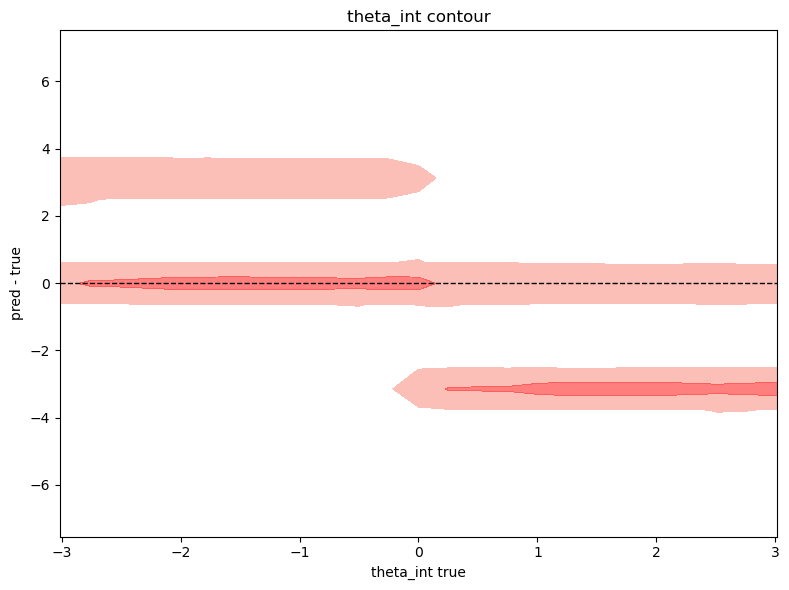

In [ ]:
_, _, out_masked = plotter.plot(
    param='theta_int',
    # mask_param='sini',
    masking_value=0.7,
    flip_mask=True,
    use_tf=False,
    nbins=25,
)

In [ ]:
print(config.par_ranges)

{'g1': [-0.1, 0.1], 'g2': [-0.1, 0.1], 'theta_int': [-3.141592653589793, 3.141592653589793], 'sini': [0.0, 1.0], 'v0': [-30.0, 30.0], 'vcirc': [60.0, 540.0], 'rscale': [0.1, 2.0], 'hlr': [0.1, 3.0], 'dx_disk': [-0.5, 0.5], 'dy_disk': [-0.5, 0.5], 'dx_spec': [-0.5, 0.5], 'dy_spec': [-0.5, 0.5]}


In [ ]:
par_range_mod = config.par_ranges.copy()
par_range_mod['theta_int'] = [-np.pi, np.pi, True]

In [ ]:
snr_target = 200
snr_tolerance = 5.0
snr_idx = np.where((np.abs(snrs - snr_target) < snr_tolerance))[0]
# snr_idx = np.arange(0, 10)
print(f'Candidates near SNR={snr_target}:', snr_idx.shape[0])

n_examples = min(10, snr_idx.shape[0])
for i in range(n_examples):
    idx = snr_idx[i]
    # mode_samples = [samples[0, idx], samples[1, idx]]
    fig, _, _ = make_corner_plot(
        samples[0, idx],
        truth=truths[idx],
        labels=config.train['feature_names'],
        sample_labels=['no TF prior'],
        suptitle=f'Galaxy {idx}, SNR={snrs[idx]:.2f}',
        ranges=par_range_mod
    )
    fig.savefig(join(fig_root, model_name, f'corner_snr_{int(snr_target)}_{i}.png'), dpi=300)
    plt.close(fig)

Candidates near SNR=200: 182
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


In [48]:
sini = np.array(sample_table['sini'])[:ngals]
hlr = np.array(sample_table['hlr'])[:ngals]

In [32]:
def binned_bias(x_true, x_diff, nbins=20):
    edges = np.linspace(-0.1, 0.1, nbins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    which = np.searchsorted(edges, x_true) - 1

    mean = np.full(nbins, np.nan, dtype=np.float64)
    err = np.full(nbins, np.nan, dtype=np.float64)

    for i in range(nbins):
        mask = which == i
        if np.any(mask):
            vals = x_diff[mask]
            mean[i] = np.mean(vals)
            err[i] = np.std(vals) / np.sqrt(vals.shape[0])

    return centers, mean, err

c1, m1, e1 = binned_bias(g1_true, g1_diff)
c2, m2, e2 = binned_bias(g2_true, g2_diff)
cp, mp, ep = binned_bias(gp_true, gp_diff)
cx, mx, ex = binned_bias(gc_true, gc_diff)

In [33]:
def binned_bias_masked(x_true, x_diff, mask, nbins=20):
    edges = np.linspace(gmin, gmax, nbins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    which = np.searchsorted(edges, x_true) - 1

    mean = np.full(nbins, np.nan, dtype=np.float64)
    err = np.full(nbins, np.nan, dtype=np.float64)

    for i in range(nbins):
        sel = (which == i) & mask
        if np.any(sel):
            vals = x_diff[sel]
            mean[i] = np.mean(vals)
            err[i] = np.std(vals) / np.sqrt(vals.shape[0])
    return centers, mean, err

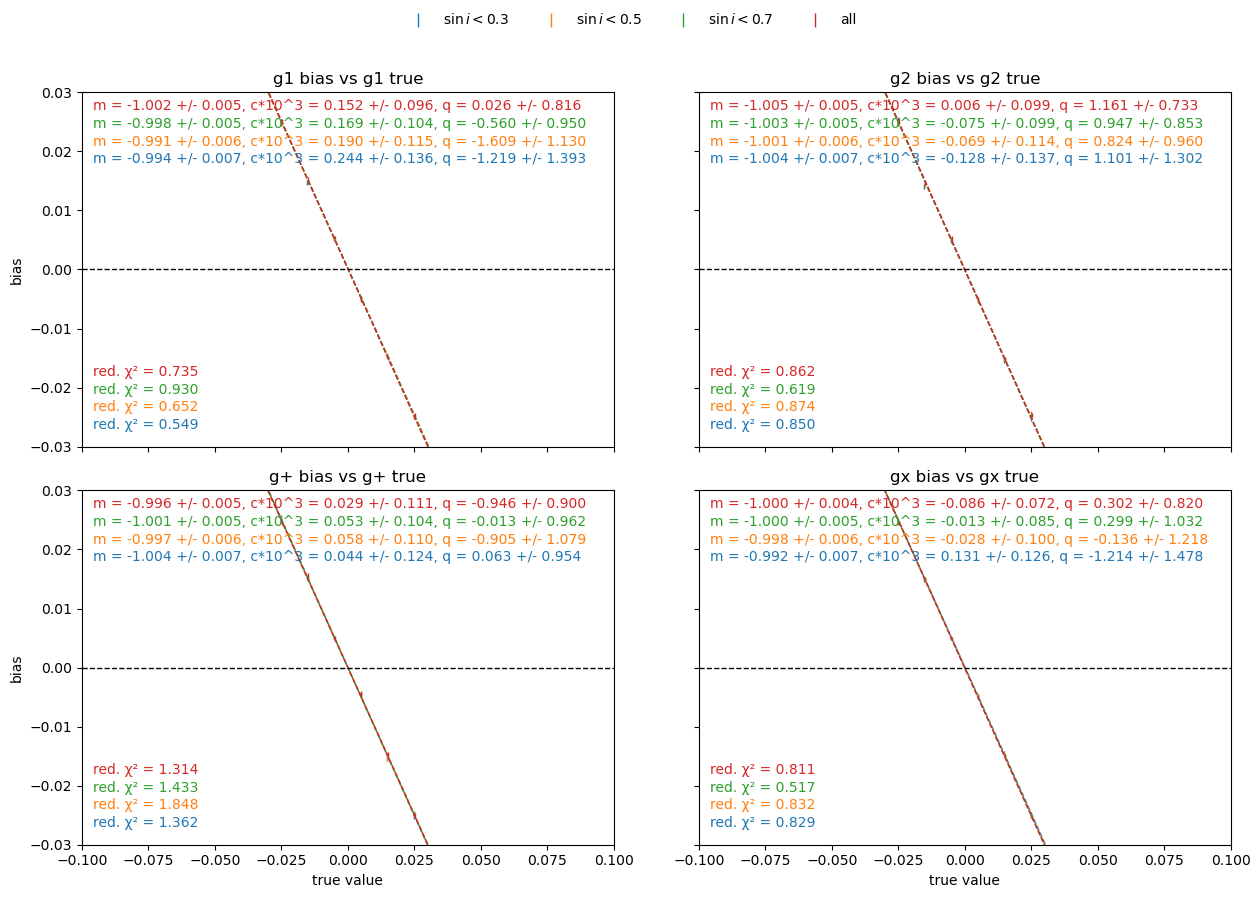

In [49]:
sini = sample_table['sini'][:ngals]
sini_cuts = [0.3, 0.5, 0.7, 1.0]
labels = [r'$\sin i < 0.3$', r'$\sin i < 0.5$', r'$\sin i < 0.7$', 'all']
plot_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
gmin, gmax = -0.1, 0.1

linear_bias = lambda x, m, c: m * x + c
cubic_bias = lambda x, m, c, q: q * x**3 + m * x + c

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
shift = 0.0
bias_model = cubic_bias  # Change to cubic_bias if you want to fit a cubic model
x = np.linspace(gmin, gmax, 100)
for cut, label, color in zip(sini_cuts, labels, plot_colors):
    if cut >= 1.0:
        mask = np.ones_like(sini, dtype=bool)
    else:
        mask = sini < cut

    popt_list = []
    pcov_list = []
    red_chi2_list = []
    for i, (g_true, g_diff) in enumerate(zip([g1_true, g2_true, gp_true, gc_true], [g1_diff, g2_diff, gp_diff, gc_diff])):
        c, m, e = binned_bias_masked(g_true, g_diff, mask)
        nanmask = ~np.isnan(m)
        popt, pcov = curve_fit(bias_model, c[nanmask], m[nanmask], sigma=e[nanmask], absolute_sigma=True)
        popt_list.append(popt)
        pcov_list.append(pcov)
        residuals = m[nanmask] - bias_model(c[nanmask], *popt)
        chi2 = np.sum((residuals / e[nanmask])**2)
        dof = np.sum(nanmask) - len(popt)
        red_chi2_list.append(chi2 / dof if dof > 0 else np.nan)
        axes[i//2, i%2].errorbar(c+0.002*shift-0.0002, m, yerr=e, lw=1, fmt='none', color=color, label=label)
        # axes[i//2, i%2].plot(c+0.002*shift-0.0002, m, lw=1, marker='.', linestyle='None', color=color, label=label)
        axes[i//2, i%2].plot(x, bias_model(x, *popt), color=color, lw=1, ls='--')
    if len(popt) == 3:
        for i, (popt, pcov) in enumerate(zip(popt_list, pcov_list)):
            ax = axes[i//2, i%2]
            ax.text(0.02, 0.80 + shift, f'm = {popt[0]:.3f} +/- {np.sqrt(pcov[0, 0]):.3f}, c*10^3 = {popt[1]*1e3:.3f} +/- {np.sqrt(pcov[1, 1])*1e3:.3f}, q = {popt[2]:.3f} +/- {np.sqrt(pcov[2, 2]):.3f}', transform=ax.transAxes, fontsize=10, color=color)
            ax.text(0.02, 0.05 + shift, f'red. χ² = {red_chi2_list[i]:.3f}', transform=ax.transAxes, fontsize=10, color=color)
    else:
        for i, (popt, pcov) in enumerate(zip(popt_list, pcov_list)):
            ax = axes[i//2, i%2]
            ax.text(0.05, 0.80 + shift, f'm = {popt[0]:.3f} +/- {np.sqrt(pcov[0, 0]):.3f}, c*10^3 = {popt[1]*1e3:.3f} +/- {np.sqrt(pcov[1, 1])*1e3:.3f}', transform=ax.transAxes, fontsize=10, color=color)
            ax.text(0.05, 0.05 + shift, f'red. χ² = {red_chi2_list[i]:.3f}', transform=ax.transAxes, fontsize=10, color=color)
    shift += 0.05  # Increment shift for the next label to avoid overlap

axes[0, 0].set_title('g1 bias vs g1 true')
axes[0, 1].set_title('g2 bias vs g2 true')
axes[1, 0].set_title('g+ bias vs g+ true')
axes[1, 1].set_title('gx bias vs gx true')

for ax in axes.ravel():
    ax.axhline(0.0, ls='--', c='k', lw=1)
    ax.set_xlim(gmin, gmax)
    ax.set_ylim(-0.03, 0.03)

axes[1, 0].set_xlabel('true value')
axes[1, 1].set_xlabel('true value')
axes[0, 0].set_ylabel('bias')
axes[1, 0].set_ylabel('bias')

handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='upper center', ncol=4, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(join(fig_root, model_name, f'bias_vs_true_sini_cuts_cubic.png'), dpi=300)
plt.show()

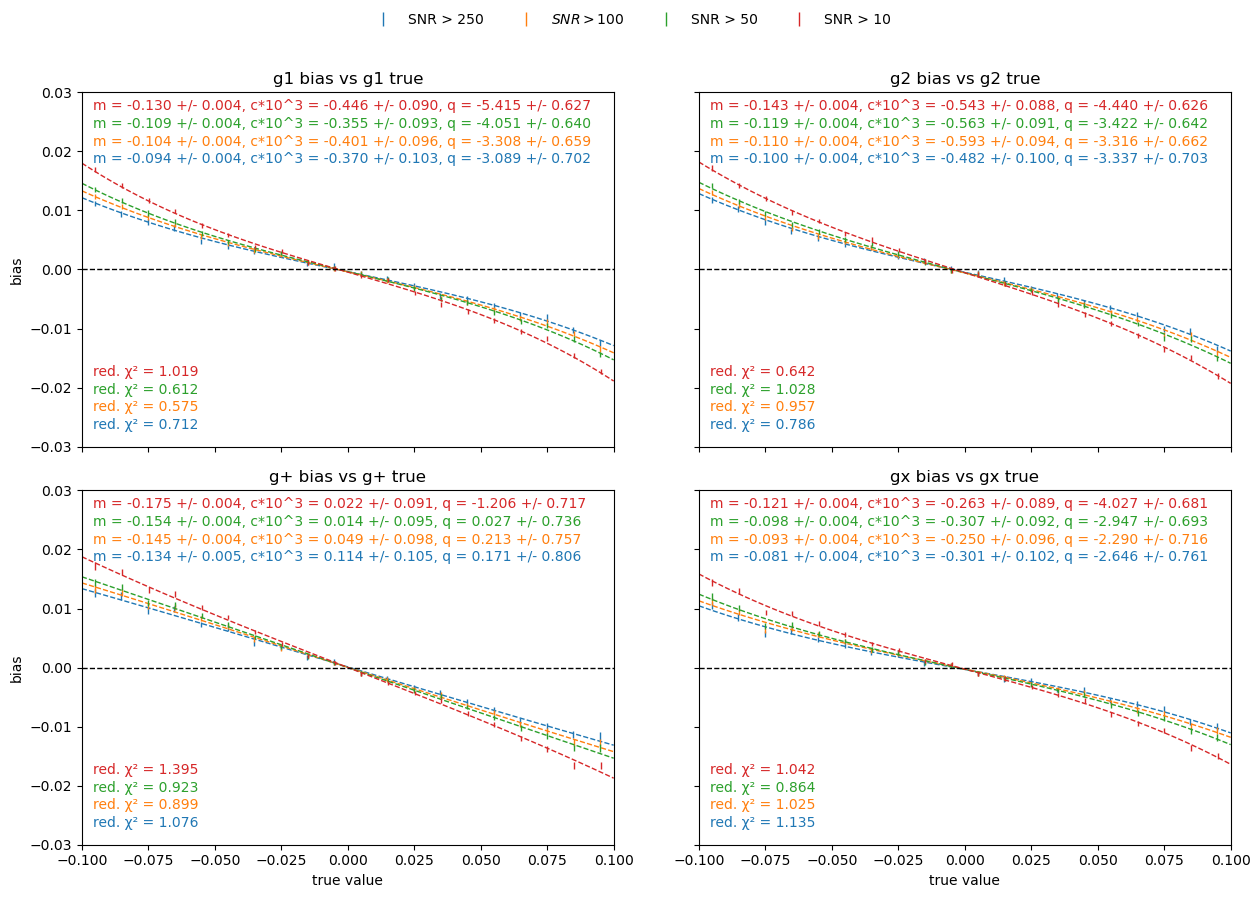

In [48]:
snr_cuts = [250, 100, 50, 10]
labels = [r'SNR > 250', r'$SNR > 100$', r'SNR > 50', 'SNR > 10']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
gmin, gmax = -0.1, 0.1

linear_bias = lambda x, m, c: m * x + c
cubic_bias = lambda x, m, c, q: q * x**3 + m * x + c

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
shift = 0.0
bias_model = cubic_bias  # Change to cubic_bias if you want to fit a cubic model
x = np.linspace(gmin, gmax, 100)
for cut, label, color in zip(snr_cuts, labels, colors):
    mask = snrs > cut

    popt_list = []
    pcov_list = []
    red_chi2_list = []
    for i, (g_true, g_diff) in enumerate(zip([g1_true, g2_true, gp_true, gc_true], [g1_diff, g2_diff, gp_diff, gc_diff])):
        c, m, e = binned_bias_masked(g_true, g_diff, mask)
        nanmask = ~np.isnan(m)
        popt, pcov = curve_fit(bias_model, c[nanmask], m[nanmask], sigma=e[nanmask], absolute_sigma=True)
        popt_list.append(popt)
        pcov_list.append(pcov)
        residuals = m[nanmask] - bias_model(c[nanmask], *popt)
        chi2 = np.sum((residuals / e[nanmask])**2)
        dof = np.sum(nanmask) - len(popt)
        red_chi2_list.append(chi2 / dof if dof > 0 else np.nan)
        axes[i//2, i%2].errorbar(c+0.002*shift-0.0002, m, yerr=e, lw=1, fmt='none', color=color, label=label)
        # axes[i//2, i%2].plot(c+0.002*shift-0.0002, m, lw=1, marker='.', linestyle='None', color=color, label=label)
        axes[i//2, i%2].plot(x, bias_model(x, *popt), color=color, lw=1, ls='--')
    if len(popt) == 3:
        for i, (popt, pcov) in enumerate(zip(popt_list, pcov_list)):
            ax = axes[i//2, i%2]
            ax.text(0.02, 0.80 + shift, f'm = {popt[0]:.3f} +/- {np.sqrt(pcov[0, 0]):.3f}, c*10^3 = {popt[1]*1e3:.3f} +/- {np.sqrt(pcov[1, 1])*1e3:.3f}, q = {popt[2]:.3f} +/- {np.sqrt(pcov[2, 2]):.3f}', transform=ax.transAxes, fontsize=10, color=color)
            ax.text(0.02, 0.05 + shift, f'red. χ² = {red_chi2_list[i]:.3f}', transform=ax.transAxes, fontsize=10, color=color)
    else:
        for i, (popt, pcov) in enumerate(zip(popt_list, pcov_list)):
            ax = axes[i//2, i%2]
            ax.text(0.05, 0.80 + shift, f'm = {popt[0]:.3f} +/- {np.sqrt(pcov[0, 0]):.3f}, c*10^3 = {popt[1]*1e3:.3f} +/- {np.sqrt(pcov[1, 1])*1e3:.3f}', transform=ax.transAxes, fontsize=10, color=color)
            ax.text(0.05, 0.05 + shift, f'red. χ² = {red_chi2_list[i]:.3f}', transform=ax.transAxes, fontsize=10, color=color)
    shift += 0.05  # Increment shift for the next label to avoid overlap

axes[0, 0].set_title('g1 bias vs g1 true')
axes[0, 1].set_title('g2 bias vs g2 true')
axes[1, 0].set_title('g+ bias vs g+ true')
axes[1, 1].set_title('gx bias vs gx true')

for ax in axes.ravel():
    ax.axhline(0.0, ls='--', c='k', lw=1)
    ax.set_xlim(gmin, gmax)
    ax.set_ylim(-0.03, 0.03)

axes[1, 0].set_xlabel('true value')
axes[1, 1].set_xlabel('true value')
axes[0, 0].set_ylabel('bias')
axes[1, 0].set_ylabel('bias')

handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='upper center', ncol=4, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(join(fig_root, model_name, f'bias_vs_true_snr_cuts_cubic.png'), dpi=300)
plt.show()

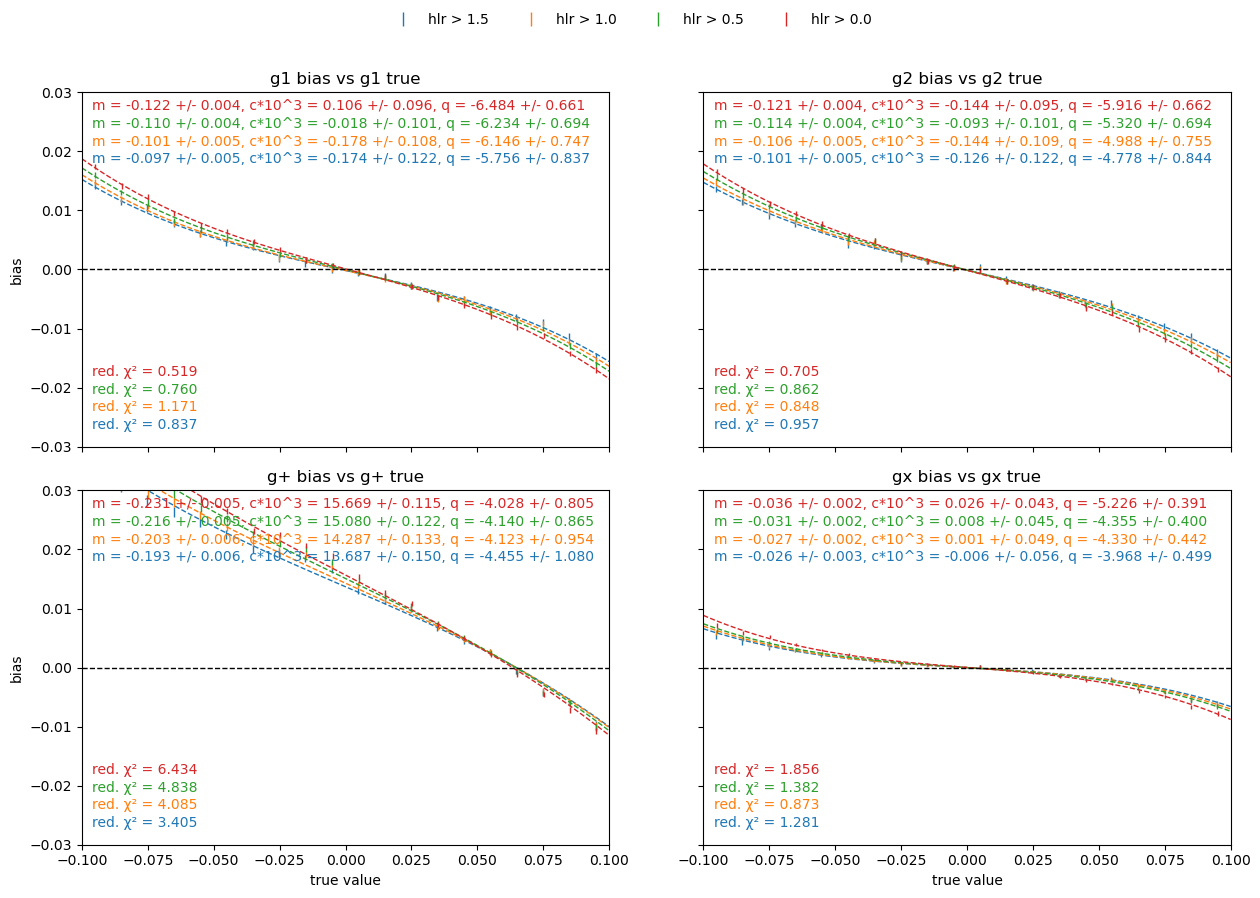

In [35]:
hlr_cuts = [1.5, 1.0, 0.5, 0.0]
labels = [r'hlr > 1.5', r'hlr > 1.0', r'hlr > 0.5', 'hlr > 0.0']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
gmin, gmax = -0.1, 0.1

linear_bias = lambda x, m, c: m * x + c
cubic_bias = lambda x, m, c, q: q * x**3 + m * x + c

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
shift = 0.0
bias_model = cubic_bias  # Change to cubic_bias if you want to fit a cubic model
x = np.linspace(gmin, gmax, 100)
for cut, label, color in zip(hlr_cuts, labels, colors):
    mask = hlr > cut

    popt_list = []
    pcov_list = []
    red_chi2_list = []
    for i, (g_true, g_diff) in enumerate(zip([g1_true, g2_true, gp_true, gc_true], [g1_diff, g2_diff, gp_diff, gc_diff])):
        c, m, e = binned_bias_masked(g_true, g_diff, mask)
        nanmask = ~np.isnan(m)
        popt, pcov = curve_fit(bias_model, c[nanmask], m[nanmask], sigma=e[nanmask], absolute_sigma=True)
        popt_list.append(popt)
        pcov_list.append(pcov)
        residuals = m[nanmask] - bias_model(c[nanmask], *popt)
        chi2 = np.sum((residuals / e[nanmask])**2)
        dof = np.sum(nanmask) - len(popt)
        red_chi2_list.append(chi2 / dof if dof > 0 else np.nan)
        axes[i//2, i%2].errorbar(c+0.002*shift-0.0002, m, yerr=e, lw=1, fmt='none', color=color, label=label)
        # axes[i//2, i%2].plot(c+0.002*shift-0.0002, m, lw=1, marker='.', linestyle='None', color=color, label=label)
        axes[i//2, i%2].plot(x, bias_model(x, *popt), color=color, lw=1, ls='--')
    if len(popt) == 3:
        for i, (popt, pcov) in enumerate(zip(popt_list, pcov_list)):
            ax = axes[i//2, i%2]
            ax.text(0.02, 0.80 + shift, f'm = {popt[0]:.3f} +/- {np.sqrt(pcov[0, 0]):.3f}, c*10^3 = {popt[1]*1e3:.3f} +/- {np.sqrt(pcov[1, 1])*1e3:.3f}, q = {popt[2]:.3f} +/- {np.sqrt(pcov[2, 2]):.3f}', transform=ax.transAxes, fontsize=10, color=color)
            ax.text(0.02, 0.05 + shift, f'red. χ² = {red_chi2_list[i]:.3f}', transform=ax.transAxes, fontsize=10, color=color)
    else:
        for i, (popt, pcov) in enumerate(zip(popt_list, pcov_list)):
            ax = axes[i//2, i%2]
            ax.text(0.05, 0.80 + shift, f'm = {popt[0]:.3f} +/- {np.sqrt(pcov[0, 0]):.3f}, c*10^3 = {popt[1]*1e3:.3f} +/- {np.sqrt(pcov[1, 1])*1e3:.3f}', transform=ax.transAxes, fontsize=10, color=color)
            ax.text(0.05, 0.05 + shift, f'red. χ² = {red_chi2_list[i]:.3f}', transform=ax.transAxes, fontsize=10, color=color)
    shift += 0.05  # Increment shift for the next label to avoid overlap

axes[0, 0].set_title('g1 bias vs g1 true')
axes[0, 1].set_title('g2 bias vs g2 true')
axes[1, 0].set_title('g+ bias vs g+ true')
axes[1, 1].set_title('gx bias vs gx true')

for ax in axes.ravel():
    ax.axhline(0.0, ls='--', c='k', lw=1)
    ax.set_xlim(gmin, gmax)
    ax.set_ylim(-0.03, 0.03)

axes[1, 0].set_xlabel('true value')
axes[1, 1].set_xlabel('true value')
axes[0, 0].set_ylabel('bias')
axes[1, 0].set_ylabel('bias')

handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='upper center', ncol=4, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(join(fig_root, model_name, f'bias_vs_true_hlr_cuts_cubic.png'), dpi=300)